In [1]:
# Import app from Custom library
from Graph.graph import app
from IPython.display import Image, display

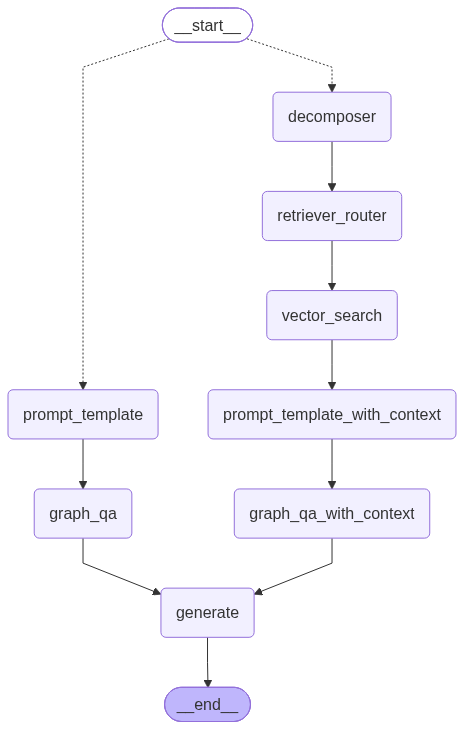

In [2]:
display(Image(app.get_graph().draw_mermaid_png()))

In [2]:
graph_qa_result = app.invoke({"question": "find top 5 models related to \"text classification\""})

---ROUTE QUESTION---
---ROUTE QUESTION TO VECTOR SEARCH---
---RETRIEVER ROUTER -> ['Model']---


> Entering new RetrievalQA chain...


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL db.index.vector.queryNodes($vector_index_name, $top_k * $effective_search_ratio, $query_vector) YIELD node, score WITH node, score LIMIT $top_k RETURN reduce(str='', k IN ['model_id', 'pipeline_tag', 'config'] | str + '\\n' + k + ': ' + coalesce(toString(node[k]), '')) AS text, node{node_id: node.model_id, label: 'Model'} AS metadata, s


> Finished chain.


CypherSyntaxError: {neo4j_code: Neo.ClientError.Statement.SyntaxError} {message: RETURN can only be used at the end of the query. (line 5, column 1 (offset: 203))
"RETURN m.model_id AS model_id, m.pipeline_tag AS pipeline_tag, r.id AS repo_id, r.name AS repo_name, collect(DISTINCT t.name) AS tags, count(DISTINCT s) AS num_spaces, collect(DISTINCT s.space_id) AS spaces"
 ^} {gql_status: 42001} {gql_status_description: error: syntax error or access rule violation - invalid syntax}

In [21]:
graph_qa_result['documents']

{'query': 'Neo4j Cypher query: Given a parameter $model_ids (list of the top 5 model ids from the similarity search), return the corresponding Model nodes with key properties in the original order. Cypher:\n\nUNWIND $model_ids AS mid\nMATCH (m:Model {id: mid})\nRETURN m { .id, .name, .description, .framework, .tags, .version, .popularity } AS model\nLIMIT 5\n\nParameters: { "model_ids": ["model_123", "model_456", ...] }',
 'result': [{'r.id': 'datasets/copenlu/spiced',
   'r.name': 'copenlu/spiced',
   't.name': 'semantic text similarity'},
  {'r.id': 'models/ahmet1338/finetuned_embedder',
   'r.name': 'ahmet1338/finetuned_embedder',
   't.name': 'text-semantic-similarity'},
  {'r.id': 'models/baseplate/instructor-large-1',
   'r.name': 'baseplate/instructor-large-1',
   't.name': 'text-semantic-similarity'},
  {'r.id': 'models/Consensus/instructor-base',
   'r.name': 'Consensus/instructor-base',
   't.name': 'text-semantic-similarity'},
  {'r.id': 'models/gentlebowl/instructor-large-s

In [23]:
graph_qa_result["answer"]

KeyError: 'answer'

In [12]:
graph_qa_result = app.invoke({"question": "What models were created by a specific author, e.g  \"google\"?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO GRAPH QA---


> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (au:Author)<-[:CREATED_BY]-(r:Repository)<-[:IS_A]-(m:Model) WHERE au.username = 'google' RETURN m.model_id

> Finished chain.


In [13]:
graph_qa_result['documents']

{'query': 'What models were created by a specific author, e.g  "google"?',
 'result': [{'m.model_id': 'models/google/bert2bert_L-24_wmt_de_en'},
  {'m.model_id': 'models/google/bert2bert_L-24_wmt_en_de'},
  {'m.model_id': 'models/google/bert_for_seq_generation_L-24_bbc_encoder'},
  {'m.model_id': 'models/google/bert_uncased_L-10_H-128_A-2'},
  {'m.model_id': 'models/google/bert_uncased_L-10_H-256_A-4'},
  {'m.model_id': 'models/google/bert_uncased_L-10_H-512_A-8'},
  {'m.model_id': 'models/google/bert_uncased_L-10_H-768_A-12'},
  {'m.model_id': 'models/google/bert_uncased_L-12_H-128_A-2'},
  {'m.model_id': 'models/google/bert_uncased_L-12_H-256_A-4'},
  {'m.model_id': 'models/google/bert_uncased_L-12_H-512_A-8'}]}

In [14]:
result = app.invoke({"question": "How many models are there in total?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO GRAPH QA---


> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Model) RETURN count(m)

> Finished chain.


In [15]:
result.keys()

dict_keys(['question', 'documents', 'prompt'])

In [16]:
result['documents']

{'query': 'How many models are there in total?',
 'result': [{'count(m)': 708377}]}

In [17]:
result['subqueries']

KeyError: 'subqueries'